<a href="https://colab.research.google.com/github/RyanZzz233/Robo_advisor/blob/main/FINAL_greedy_search_MAANG_Regime_Switching_Strategy_LONGSHORT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Long-Short Regime-Switching Strategy Implementation

This project implements a **long-short regime-switching strategy** on an equal-weighted portfolio of MAANG stocks (META, AAPL, AMZN, NFLX, GOOGL) over the period 2015–2019. The strategy is designed to take both **long** and **short** positions depending on the detected market regime and signal direction, rather than behaving like a passive buy-and-hold portfolio.

### Regime Detection
For each stock, the market state is classified as either a **trend regime** or a **range regime** using the normalized distance between the fast and slow moving averages:

$$
\text{Strength}_t = \frac{|MA_{\text{fast},t} - MA_{\text{slow},t}|}{P_t}
$$

If the strength exceeds a ticker-specific threshold, the stock is classified as being in a **trend regime**; otherwise, it is treated as being in a **range regime**. Ticker-specific thresholds are used because different MAANG stocks exhibit different volatility and trend persistence characteristics.

## Trading Logic

### 1. Trend Regime
In the trend regime, the strategy trades in the direction of the prevailing trend.

#### Long Entry
A long signal is generated when:
- the fast moving average is above the slow moving average,
- the price is above the slow moving average.

#### Short Entry
A short signal is generated when:
- the fast moving average is below the slow moving average,
- the price is below the slow moving average,
- RSI is below 50, confirming bearish momentum.

#### Long Exit
A long position is closed when:
- the fast moving average falls below the slow moving average, or
- the price falls below the slow moving average, or
- the trailing stop is triggered.

#### Short Exit
A short position is covered when:
- the fast moving average rises above the slow moving average, or
- the price rises above the slow moving average, or
- RSI rises above 50, suggesting bearish momentum is weakening, or
- the trailing stop is triggered.

### 2. Range Regime
In the range regime, the strategy follows a mean-reversion logic using Bollinger Bands and RSI.

#### Long Entry
A long signal is generated when:
- the price falls below the lower Bollinger Band,
- RSI is below the long-entry threshold.

#### Short Entry
A short signal is generated when:
- the price rises above the upper Bollinger Band,
- RSI is above the short-entry threshold.

#### Long Exit
A long position is closed when:
- the price returns to the Bollinger Band midline, or
- RSI rises above the long-exit threshold.

#### Short Exit
A short position is covered when:
- the price falls back to the Bollinger Band midline, or
- RSI falls below the short-exit threshold.

## Position Management and Risk Control

The strategy uses a **state-based position system**:
- `+1` = long
- `0` = flat
- `-1` = short

This allows the strategy to switch between long, short, and no position depending on the signal environment.

### Trailing Stop
A trailing stop is applied symmetrically to both long and short positions.

For long positions:

$$
\text{StopPrice}_t = \text{Peak}_t \times (1 - \tau_t)
$$

where $\text{Peak}_t$ is the highest price reached since entry.

For short positions:

$$
\text{StopPrice}_t = \text{Trough}_t \times (1 + \tau_t)
$$

where $\text{Trough}_t$ is the lowest price reached since entry.

### Dynamic Profit Tightening
To preserve profits after a strong move, the trailing stop is tightened once a trade achieves a target unrealized gain.

Formally:

$$
\tau_t =
\begin{cases}
\tau_{\text{initial}}, & \text{if profit} < \theta \\
\tau_{\text{tight}}, & \text{if profit} \ge \theta
\end{cases}
$$

where:
- $\theta$ is the profit-tightening threshold,
- $\tau_{\text{initial}}$ is the original trailing stop,
- $\tau_{\text{tight}}$ is the tighter stop once sufficient profit has been reached.

This mechanism helps reduce profit give-back while still allowing winning trades to develop.

## Return Calculation

Daily strategy returns are computed by multiplying the stock's daily percentage return by the previous day's position:

```python
rets = c.pct_change() * pos.shift(1)
```

This is important because it avoids **look-ahead bias**: the strategy only earns tomorrow's return after today's signal has been formed.

- If `position = +1`, the strategy earns the stock return.
- If `position = -1`, the strategy earns the inverse of the stock return.
- If `position = 0`, the strategy earns zero.

Per-ticker strategy returns are then combined into an **equal-weighted portfolio return series**.

---

## Parameter Optimization

A **greedy coordinate-ascent search** is used to tune the strategy parameters by maximizing **Sharpe ratio in-sample**. The search explores the following parameters:

- fast and slow moving average windows  
- RSI lookback period  
- Bollinger Band window and width  
- long-entry and long-exit RSI thresholds  
- short-entry and short-exit RSI thresholds  
- trailing stop percentage  
- profit-tightening threshold  
- tightened trailing stop  
- ticker-specific trend thresholds  

The parameter search is constrained to ensure economically sensible combinations, such as:

- `MA_FAST < MA_SLOW`
- `RSI_RANGE_ENTRY < RSI_RANGE_EXIT`
- `RSI_SHORT_EXIT < RSI_SHORT_ENTRY`
- `TIGHT_TRAIL <= TRAIL_PCT`

---

## Interpretation

This **long-short regime-switching framework** attempts to exploit two different types of market behaviour:

- **trend-following** when markets show directional persistence  
- **mean-reversion** when markets move sideways within a range  

The addition of shorting allows the strategy to participate not only in bullish opportunities but also in bearish moves, which aligns with the project requirement that the strategy should be **long-short rather than buy-and-hold**.

Overall, the strategy is designed to improve **risk-adjusted performance** through:

- adaptive regime classification  
- symmetric long/short execution  
- volatility-sensitive thresholds  
- disciplined exit rules  
- dynamic risk management

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Fixed Settings
# ----------------------------
TICKERS = ["META", "AAPL", "AMZN", "NFLX", "GOOGL"]
START, END = "2014-01-01", "2019-12-31"
TRADE_START = "2015-01-01"
ANNUALIZATION = 252

# Toggle: set to False to disable shorting everywhere
ENABLE_SHORTING = True

# ----------------------------
# Indicators
# ----------------------------
def compute_rsi(close: pd.Series, n: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/n, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/n, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def compute_bbands(close: pd.Series, n: int = 20, k: float = 2.0):
    mid = close.rolling(n).mean()
    sd = close.rolling(n).std(ddof=0)
    lower = mid - k * sd
    upper = mid + k * sd
    return lower, mid, upper

def get_metrics(returns: pd.Series) -> dict:
    returns = returns[returns.index >= pd.Timestamp(TRADE_START)].dropna()
    if len(returns) < 30:
        return {"Return": np.nan, "CAGR": np.nan, "Sharpe": np.nan, "Sortino": np.nan, "MaxDD": np.nan}

    equity = (1 + returns).cumprod()
    total_ret = equity.iloc[-1] - 1
    years = len(returns) / ANNUALIZATION
    cagr = (equity.iloc[-1]) ** (1 / years) - 1

    vol = returns.std()
    sharpe = (returns.mean() / vol) * np.sqrt(ANNUALIZATION) if vol and vol > 0 else np.nan

    downside = returns[returns < 0]
    downside_std = downside.std() * np.sqrt(ANNUALIZATION)
    sortino = (returns.mean() * ANNUALIZATION) / downside_std if downside_std and downside_std > 0 else np.nan

    dd = equity / equity.cummax() - 1
    max_dd = dd.min()

    return {"Return": total_ret, "CAGR": cagr, "Sharpe": sharpe, "Sortino": sortino, "MaxDD": max_dd}

# ----------------------------
# Data Load (do once)
# ----------------------------
def load_prices(tickers=TICKERS, start=START, end=END) -> pd.DataFrame:
    prices = yf.download(tickers, start=start, end=end)["Close"]

    # Handle META/FB ticker change for older data
    if "META" in prices.columns and prices["META"].isnull().mean() > 0.5:
        fb = yf.download("FB", start=start, end=end)["Close"]
        prices["META"] = prices["META"].combine_first(fb)

    return prices.ffill()

# ----------------------------
# Backtest as a function (LONG-SHORT in BOTH regimes)
# ----------------------------
def run_backtest(
    prices: pd.DataFrame,
    params: dict,
    tickers=TICKERS,
    trade_start=TRADE_START
):
    '''
    Long-short regime-switching backtest.

    Position states:
      +1 = long, 0 = flat, -1 = short

    params keys expected:
      - MA_FAST (int), MA_SLOW (int)
      - RSI_N (int), BB_N (int), BB_K (float)
      - TREND_THRESHOLDS (dict[ticker]->float) or TREND_TH_GLOBAL (float)
      - RSI_RANGE_ENTRY, RSI_RANGE_EXIT       (range long)
      - RSI_SHORT_ENTRY, RSI_SHORT_EXIT       (range short)
      - TRAIL_PCT (float)
      - PROFIT_TIGHTEN_LEVEL (float), TIGHT_TRAIL (float)
      - ENABLE_SHORTING (bool) optional override for global ENABLE_SHORTING
    '''
    ma_fast = int(params["MA_FAST"])
    ma_slow = int(params["MA_SLOW"])
    rsi_n = int(params["RSI_N"])
    bb_n = int(params["BB_N"])
    bb_k = float(params["BB_K"])

    # range long thresholds
    rsi_long_entry = float(params["RSI_RANGE_ENTRY"])
    rsi_long_exit  = float(params["RSI_RANGE_EXIT"])

    # range short thresholds (defaults)
    rsi_short_entry = float(params.get("RSI_SHORT_ENTRY", 70))
    rsi_short_exit  = float(params.get("RSI_SHORT_EXIT", 50))

    # trailing stop & profit tightening
    trail_pct = float(params["TRAIL_PCT"])
    profit_tighten_level = float(params.get("PROFIT_TIGHTEN_LEVEL", 0.20))
    tight_trail = float(params.get("TIGHT_TRAIL", 0.05))

    # enable/disable shorts
    enable_shorting = bool(params.get("ENABLE_SHORTING", ENABLE_SHORTING))

    # trend thresholds: either per ticker dict, or global scalar
    if "TREND_THRESHOLDS" in params and isinstance(params["TREND_THRESHOLDS"], dict):
        trend_th = params["TREND_THRESHOLDS"]
    else:
        th = float(params.get("TREND_TH_GLOBAL", 0.03))
        trend_th = {t: th for t in tickers}

    trade_logs = []
    all_strat_rets = []
    regime_map = pd.DataFrame(index=prices.index)

    for t in tickers:
        c = prices[t].dropna()
        if len(c) < ma_slow + 10:
            continue

        ma_f = c.rolling(ma_fast).mean()
        ma_s = c.rolling(ma_slow).mean()

        rsi = compute_rsi(c, n=rsi_n)
        bb_l, bb_m, bb_u = compute_bbands(c, n=bb_n, k=bb_k)

        # Regime detection
        strength = (ma_f - ma_s).abs() / c
        current_th = float(trend_th.get(t, 0.03))
        regime = (strength > current_th).astype(int).rolling(5).median().fillna(0)
        regime_map[t] = regime

        # Position series: +1 long, 0 flat, -1 short
        pos = pd.Series(0.0, index=c.index)

        pos_state = 0
        entry_price = 0.0
        peak = 0.0        # for long trailing stop
        trough = np.inf   # for short trailing stop

        for i in range(1, len(c)):
            dt = c.index[i]
            p = float(c.iloc[i])

            if dt < pd.Timestamp(trade_start):
                continue

            curr_regime = int(regime.iloc[i])

            # -------------------------
            # Signals (both regimes)
            # -------------------------

          #  # Trend regime: direction by MA relationship + price confirmation
          #   trend_long_signal  = (curr_regime == 1 and ma_f.iloc[i] > ma_s.iloc[i] and p > ma_s.iloc[i])
          #   trend_short_signal = (curr_regime == 1 and ma_f.iloc[i] < ma_s.iloc[i] and p < ma_s.iloc[i] and rsi.iloc[i] < 50)

          #   # Range regime: mean reversion both directions
          #   range_long_signal  = (curr_regime == 0 and p < bb_l.iloc[i] and rsi.iloc[i] < rsi_long_entry)
          #   range_short_signal = (curr_regime == 0 and p > bb_u.iloc[i] and rsi.iloc[i] > rsi_short_entry)

          #   # Range exits (return to mean / momentum fades)
          #   range_long_exit  = (curr_regime == 0 and (p >= bb_m.iloc[i] or rsi.iloc[i] > rsi_long_exit))
          #   range_short_exit = (curr_regime == 0 and (p <= bb_m.iloc[i] or rsi.iloc[i] < rsi_short_exit))

          #   # Trend exits (signal invalidation / reversal)
          #   trend_long_exit  = (curr_regime == 1 and (ma_f.iloc[i] < ma_s.iloc[i] or p < ma_s.iloc[i]))
          #   trend_short_exit = (curr_regime == 1 and (ma_f.iloc[i] > ma_s.iloc[i] or p > ma_s.iloc[i] or rsi.iloc[i] > 50))

            # Trend regime: direction by MA relationship + price confirmation + RSI momentum confirmation
            trend_long_signal  = (curr_regime == 1 and ma_f.iloc[i] > ma_s.iloc[i] and p > ma_s.iloc[i])
            trend_short_signal = (curr_regime == 1 and ma_f.iloc[i] < ma_s.iloc[i] and p < ma_s.iloc[i] and rsi.iloc[i] < 50)

            # Range regime: mean reversion both directions
            range_long_signal  = (curr_regime == 0 and p < bb_l.iloc[i] and rsi.iloc[i] < rsi_long_entry)
            range_short_signal = (curr_regime == 0 and p > bb_u.iloc[i] and rsi.iloc[i] > rsi_short_entry)

            # Range exits
            range_long_exit  = (curr_regime == 0 and (p >= bb_m.iloc[i] or rsi.iloc[i] > rsi_long_exit))
            range_short_exit = (curr_regime == 0 and (p <= bb_m.iloc[i] or rsi.iloc[i] < rsi_short_exit))

            # Trend exits (signal invalidation / reversal)
            trend_long_exit  = (curr_regime == 1 and (ma_f.iloc[i] < ma_s.iloc[i] or p < ma_s.iloc[i]))
            trend_short_exit = (curr_regime == 1 and (ma_f.iloc[i] > ma_s.iloc[i] or p > ma_s.iloc[i] or rsi.iloc[i] > 50))

            # If shorting disabled, ignore all short signals
            if not enable_shorting:
                trend_short_signal = False
                range_short_signal = False

            # -------------------------
            # Trailing stop (symmetric)
            # -------------------------
            trail_stop = False
            stop_reason = None

            if pos_state == 1:
                peak = max(peak, p)

                current_trail = trail_pct
                if entry_price > 0 and (peak / entry_price - 1) >= profit_tighten_level:
                    current_trail = tight_trail

                trail_stop = p <= peak * (1 - current_trail)
                if trail_stop:
                    stop_reason = "Stop"

            elif pos_state == -1:
                trough = min(trough, p)

                current_trail = trail_pct
                if np.isfinite(trough) and trough > 0 and entry_price > 0 and (entry_price / trough - 1) >= profit_tighten_level:
                    current_trail = tight_trail

                # for shorts: stop if price rebounds above trough by trailing%
                trail_stop = p >= trough * (1 + current_trail)
                if trail_stop:
                    stop_reason = "Stop"

            # -------------------------
            # State machine (enter/exit/flip)
            # -------------------------
            if pos_state == 0:
                # prioritize trend signals over range signals
                if trend_long_signal:
                    pos_state = 1
                    entry_price = p
                    peak = p
                    trough = np.inf
                    trade_logs.append([dt, t, "BUY", p, "Trend-Long"])

                elif trend_short_signal:
                    pos_state = -1
                    entry_price = p
                    trough = p
                    peak = 0.0
                    trade_logs.append([dt, t, "SHORT", p, "Trend-Short"])

                elif range_long_signal:
                    pos_state = 1
                    entry_price = p
                    peak = p
                    trough = np.inf
                    trade_logs.append([dt, t, "BUY", p, "Range-Long"])

                elif range_short_signal:
                    pos_state = -1
                    entry_price = p
                    trough = p
                    peak = 0.0
                    trade_logs.append([dt, t, "SHORT", p, "Range-Short"])

            elif pos_state == 1:
                # exit long on stop or regime-appropriate exit rules
                exit_now = trail_stop or trend_long_exit or range_long_exit
                if exit_now:
                    trade_logs.append([dt, t, "SELL", p, stop_reason if stop_reason else "Exit"])
                    pos_state = 0

                # optional flip: after exiting, if an opposite signal is present, enter immediately
                if pos_state == 0 and enable_shorting and (trend_short_signal or range_short_signal):
                    pos_state = -1
                    entry_price = p
                    trough = p
                    peak = 0.0
                    trade_logs.append([dt, t, "SHORT", p, "Flip-to-Short"])

            elif pos_state == -1:
                # exit short (cover) on stop or exit rules
                exit_now = trail_stop or trend_short_exit or range_short_exit
                if exit_now:
                    trade_logs.append([dt, t, "COVER", p, stop_reason if stop_reason else "Exit"])
                    pos_state = 0

                if pos_state == 0 and (trend_long_signal or range_long_signal):
                    pos_state = 1
                    entry_price = p
                    peak = p
                    trough = np.inf
                    trade_logs.append([dt, t, "BUY", p, "Flip-to-Long"])

            pos.iloc[i] = float(pos_state)

        # Long-short returns: pos = -1 automatically profits on down days
        rets = (c.pct_change() * pos.shift(1)).rename(t)
        all_strat_rets.append(rets)

    if not all_strat_rets:
        return {"Return": np.nan, "CAGR": np.nan, "Sharpe": np.nan, "Sortino": np.nan, "MaxDD": np.nan}, pd.DataFrame(), pd.Series(dtype=float), pd.DataFrame()

    strat_rets = pd.concat(all_strat_rets, axis=1).mean(axis=1)
    metrics = get_metrics(strat_rets)
    trades_df = pd.DataFrame(trade_logs, columns=["Date", "Ticker", "Side", "Price", "Reason"])

    return metrics, trades_df, strat_rets, regime_map

# ----------------------------
# Greedy (coordinate ascent) search
# ----------------------------
def greedy_search(
    prices: pd.DataFrame,
    base_params: dict,
    search_space: dict,
    objective: str = "Sharpe",
    max_passes: int = 5,
    verbose: bool = True,
):
    '''Coordinate-ascent greedy search over a small parameter grid.'''

    def score_from_metrics(m):
        v = m.get(objective, np.nan)
        return -np.inf if (v is None or np.isnan(v)) else float(v)

    def is_valid(temp_params):
        # MA ordering
        if "MA_FAST" in temp_params and "MA_SLOW" in temp_params:
            if int(temp_params["MA_FAST"]) >= int(temp_params["MA_SLOW"]):
                return False
        # Range RSI ordering (long)
        if "RSI_RANGE_ENTRY" in temp_params and "RSI_RANGE_EXIT" in temp_params:
            if float(temp_params["RSI_RANGE_ENTRY"]) >= float(temp_params["RSI_RANGE_EXIT"]):
                return False
        # Range RSI ordering (short): exit < entry
        if "RSI_SHORT_ENTRY" in temp_params and "RSI_SHORT_EXIT" in temp_params:
            if float(temp_params["RSI_SHORT_EXIT"]) >= float(temp_params["RSI_SHORT_ENTRY"]):
                return False
        # Tight trail should usually be <= normal trail
        if "TIGHT_TRAIL" in temp_params and "TRAIL_PCT" in temp_params:
            if float(temp_params["TIGHT_TRAIL"]) > float(temp_params["TRAIL_PCT"]):
                return False
        # profit tighten level > 0
        if "PROFIT_TIGHTEN_LEVEL" in temp_params:
            if float(temp_params["PROFIT_TIGHTEN_LEVEL"]) <= 0:
                return False
        return True

    best_params = {k: v for k, v in base_params.items()}
    best_metrics, _, _, _ = run_backtest(prices, best_params)
    best_score = score_from_metrics(best_metrics)

    if verbose:
        print("Initial:", best_metrics, "score=", best_score)

    for p in range(max_passes):
        improved = False

        # 1) scalar params
        for key, candidates in search_space.items():
            if key == "TREND_THRESHOLDS":
                continue

            if not isinstance(candidates, (list, tuple)):
                continue

            local_best_val = best_params.get(key)
            local_best_score = best_score
            local_best_metrics = best_metrics

            for val in candidates:
                temp = {k: v for k, v in best_params.items()}
                temp[key] = val
                if not is_valid(temp):
                    continue

                m, _, _, _ = run_backtest(prices, temp)
                s = score_from_metrics(m)
                if s > local_best_score:
                    local_best_score = s
                    local_best_val = val
                    local_best_metrics = m

            if local_best_score > best_score:
                best_score = local_best_score
                best_params[key] = local_best_val
                best_metrics = local_best_metrics
                improved = True
                if verbose:
                    print(f"Pass {p+1}: improved {key} -> {local_best_val} | {objective}={best_score:.4f}")
                    print(f"metrics: {best_metrics}")
                    print(f"params: {best_params}")

        # 2) per-ticker threshold tuning
        if "TREND_THRESHOLDS" in search_space:
            per_ticker_space = search_space["TREND_THRESHOLDS"]
            if "TREND_THRESHOLDS" not in best_params or not isinstance(best_params["TREND_THRESHOLDS"], dict):
                base_th = float(best_params.get("TREND_TH_GLOBAL", 0.03))
                best_params["TREND_THRESHOLDS"] = {t: base_th for t in TICKERS}

            for tkr, candidates in per_ticker_space.items():
                local_best_val = best_params["TREND_THRESHOLDS"].get(tkr, 0.03)
                local_best_score = best_score
                local_best_metrics = best_metrics

                for val in candidates:
                    temp = {k: v for k, v in best_params.items()}
                    temp_th = dict(best_params["TREND_THRESHOLDS"])
                    temp_th[tkr] = float(val)
                    temp["TREND_THRESHOLDS"] = temp_th

                    m, _, _, _ = run_backtest(prices, temp)
                    s = score_from_metrics(m)
                    if s > local_best_score:
                        local_best_score = s
                        local_best_val = float(val)
                        local_best_metrics = m

                if local_best_score > best_score:
                    best_score = local_best_score
                    best_params["TREND_THRESHOLDS"][tkr] = local_best_val
                    best_metrics = local_best_metrics
                    improved = True
                    if verbose:
                        print(f"Pass {p+1}: improved TREND_THRESHOLDS[{tkr}] -> {local_best_val} | {objective}={best_score:.4f}")
                        print(f"metrics: {best_metrics}")
                        print(f"params: {best_params}")

        if not improved:
            if verbose:
                print(f"Stopped after pass {p+1}: no further improvement.")
            break

    return best_params, best_metrics

# ----------------------------
# Example usage
# ----------------------------
prices = load_prices()

# base_params = {
#     'MA_FAST': 50,
#     'MA_SLOW': 200,
#     'RSI_N': 13,
#     'BB_N': 30,
#     'BB_K': 1.5,
#     'TREND_THRESHOLDS': {
#         'AAPL': 0.04,
#         'GOOGL': 0.04,
#         'AMZN': 0.04,
#         'NFLX': 0.04,
#         'META': 0.04
#     },
#     # Range long thresholds
#     'RSI_RANGE_ENTRY': 35,
#     'RSI_RANGE_EXIT': 50,
#     # Range short thresholds
#     'RSI_SHORT_ENTRY': 80,
#     'RSI_SHORT_EXIT': 50,
#     # Risk mgmt
#     'TRAIL_PCT': 0.06,
#     'PROFIT_TIGHTEN_LEVEL': 0.13,
#     'TIGHT_TRAIL': 0.045,
#     # Toggle
#     'ENABLE_SHORTING': ENABLE_SHORTING}
#base_params = {'MA_FAST': 100, 'MA_SLOW': 250, 'RSI_N': 12, 'BB_N': 35, 'BB_K': 1.5, 'TREND_THRESHOLDS': {'AAPL': 0.03, 'GOOGL': 0.12, 'AMZN': 0.045, 'NFLX': 0.09, 'META': 0.18}, 'RSI_RANGE_ENTRY': 30, 'RSI_RANGE_EXIT': 40, 'RSI_SHORT_ENTRY': 80, 'RSI_SHORT_EXIT': 40, 'TRAIL_PCT': 0.1, 'PROFIT_TIGHTEN_LEVEL': 0.13, 'TIGHT_TRAIL': 0.04, 'ENABLE_SHORTING': ENABLE_SHORTING}
base_params = {'MA_FAST': 15, 'MA_SLOW': 250, 'RSI_N': 12, 'BB_N': 35, 'BB_K': 1.5, 'TREND_THRESHOLDS': {'AAPL': 0.03, 'GOOGL': 0.12, 'AMZN': 0.045, 'NFLX': 0.09, 'META': 0.18}, 'RSI_RANGE_ENTRY': 35, 'RSI_RANGE_EXIT': 40, 'RSI_SHORT_ENTRY': 80, 'RSI_SHORT_EXIT': 40, 'TRAIL_PCT': 0.1, 'PROFIT_TIGHTEN_LEVEL': 0.13, 'TIGHT_TRAIL': 0.04, 'ENABLE_SHORTING': ENABLE_SHORTING}

search_space = {
    "MA_FAST": [15, 20, 30, 50, 60, 70, 80, 90, 100],
    # "MA_SLOW": [150, 200, 250, 300],
    # "MA_FAST": [i for i in range(5, 101, 10)],          # 5,15,25,...,95
    "MA_SLOW": [150, 200, 250],                    # <-- includes 200

    "RSI_N": [5, 6, 7, 8, 9, 10, 11, 12, 13],
    "BB_N": [15, 20, 25, 30, 35],
    "BB_K": [1.0, 1.5, 2.0, 2.5, 3.0],

    "RSI_RANGE_ENTRY": [25, 30, 35, 40],
    "RSI_RANGE_EXIT": [40, 45, 50, 55, 60, 65],

    "RSI_SHORT_ENTRY": [60, 65, 70, 75, 80],
    "RSI_SHORT_EXIT": [40, 45, 50, 55],

    "TRAIL_PCT": [0.05, 0.06, 0.07, 0.08, 0.09, 0.10],
    "PROFIT_TIGHTEN_LEVEL": [0.12, 0.13, 0.135, 0.14, 0.145, 0.15],
    "TIGHT_TRAIL": [0.025, 0.03, 0.035, 0.04, 0.045, 0.05],

    "TREND_THRESHOLDS": {
        "AAPL":  [0.02, 0.03, 0.04, 0.045, 0.05, 0.08, 0.085, 0.09, 0.1, 0.11, 0.12, 0.14, 0.16, 0.18],
        "GOOGL": [0.02, 0.03, 0.04, 0.045, 0.05, 0.08, 0.085, 0.09, 0.1, 0.11, 0.12, 0.14, 0.16, 0.18],
        "AMZN":  [0.02, 0.03, 0.04, 0.045, 0.05, 0.08, 0.085, 0.09, 0.1, 0.11, 0.12, 0.14, 0.16, 0.18],
        "META":  [0.02, 0.03, 0.04, 0.045, 0.05, 0.08, 0.085, 0.09, 0.1, 0.11, 0.12, 0.14, 0.16, 0.18],
        "NFLX":  [0.02, 0.03, 0.04, 0.045, 0.05, 0.08, 0.085, 0.09, 0.1, 0.11, 0.12, 0.14, 0.16, 0.18],
    },
}

best_params, best_metrics = greedy_search(
    prices=prices,
    base_params=base_params,
    search_space=search_space,
    objective="Sharpe",
    max_passes=6,
    verbose=True
)

print("\nBest metrics:", best_metrics)
print("Best params:", best_params)



[*********************100%***********************]  5 of 5 completed


Initial: {'Return': np.float64(1.3751679594533694), 'CAGR': np.float64(0.18937332565040155), 'Sharpe': np.float64(1.3401336734936937), 'Sortino': np.float64(1.6910709052099633), 'MaxDD': -0.1346921849127043} score= 1.3401336734936937
Pass 1: improved MA_FAST -> 100 | Sharpe=1.7684
metrics: {'Return': np.float64(1.740831371930827), 'CAGR': np.float64(0.22401143854843864), 'Sharpe': np.float64(1.7684033154748715), 'Sortino': np.float64(2.2005064211722805), 'MaxDD': -0.10437479210344836}
params: {'MA_FAST': 100, 'MA_SLOW': 250, 'RSI_N': 12, 'BB_N': 35, 'BB_K': 1.5, 'TREND_THRESHOLDS': {'AAPL': 0.03, 'GOOGL': 0.12, 'AMZN': 0.045, 'NFLX': 0.09, 'META': 0.18}, 'RSI_RANGE_ENTRY': 35, 'RSI_RANGE_EXIT': 40, 'RSI_SHORT_ENTRY': 80, 'RSI_SHORT_EXIT': 40, 'TRAIL_PCT': 0.1, 'PROFIT_TIGHTEN_LEVEL': 0.13, 'TIGHT_TRAIL': 0.04, 'ENABLE_SHORTING': True}
Pass 1: improved BB_K -> 2.0 | Sharpe=1.8285
metrics: {'Return': np.float64(1.7482678154241635), 'CAGR': np.float64(0.22467650212614276), 'Sharpe': np.fl

In [ ]:
# # if start with smallest value for all parms, best Sharpe Ratio
# {'Return': np.float64(1.3734467287632484), 'CAGR': np.float64(0.18920048174799242), 'Sharpe': np.float64(1.3592423912376146), 'Sortino': np.float64(1.7047829001304073), 'MaxDD': -0.1105860274470587}
# params = {'MA_FAST': 80, 'MA_SLOW': 200, 'RSI_N': 10, 'BB_N': 30, 'BB_K': 1.5,
#           'TREND_THRESHOLDS': {'AAPL': 0.02, 'GOOGL': 0.05, 'AMZN': 0.02, 'NFLX': 0.14, 'META': 0.04},
#           'RSI_RANGE_ENTRY': 30, 'RSI_RANGE_EXIT': 50, 'TRAIL_PCT': 0.1}

# Best metrics: {'Return': np.float64(1.6412124015343634), 'CAGR': np.float64(0.21496006636806597), 'Sharpe': np.float64(1.5417043147793115), 'Sortino': np.float64(1.9915191654865498), 'MaxDD': -0.09103233798483612}
# params= {'MA_FAST': 80, 'MA_SLOW': 200, 'RSI_N': 10, 'BB_N': 30, 'BB_K': 1.5,
#          'TREND_THRESHOLDS': {'AAPL': 0.02, 'GOOGL': 0.075, 'AMZN': 0.02, 'NFLX': 0.14, 'META': 0.035},
#          'RSI_RANGE_ENTRY': 30, 'RSI_RANGE_EXIT': 50, 'TRAIL_PCT': 0.1}

# Best metrics: {'Return': np.float64(1.6962045269397978), 'CAGR': np.float64(0.21998973533403232), 'Sharpe': np.float64(1.6200053136489712), 'Sortino': np.float64(2.1100479717191543), 'MaxDD': -0.0803599690087694}
# params= {'MA_FAST': 80, 'MA_SLOW': 200, 'RSI_N': 9, 'BB_N': 30, 'BB_K': 1.5, 'TREND_THRESHOLDS': {'AAPL': 0.02, 'GOOGL': 0.12, 'AMZN': 0.02, 'NFLX': 0.14, 'META': 0.035}, 'RSI_RANGE_ENTRY': 30, 'RSI_RANGE_EXIT': 50, 'TRAIL_PCT': 0.1}

# Best metrics: {'Return': np.float64(1.7866786177548186), 'CAGR': np.float64(0.22808896499543252), 'Sharpe': np.float64(1.431329422490891), 'Sortino': np.float64(1.9810773758315756), 'MaxDD': -0.16092490259907777}
# Best params: {'MA_FAST': 80, 'MA_SLOW': 250, 'RSI_N': 10, 'BB_N': 35, 'BB_K': 2.0, 'TREND_THRESHOLDS': {'AAPL': 0.03, 'GOOGL': 0.1, 'AMZN': 0.015, 'NFLX': 0.1, 'META': 0.045}, 'RSI_RANGE_ENTRY': 35, 'RSI_RANGE_EXIT': 40, 'RSI_SHORT_ENTRY': 65, 'RSI_SHORT_EXIT': 55, 'TRAIL_PCT': 0.06, 'PROFIT_TIGHTEN_LEVEL': 0.135, 'TIGHT_TRAIL': 0.045, 'ENABLE_SHORTING': True}
# best_params = {
#     'MA_FAST': 80,
#     'MA_SLOW': 200,
#     'RSI_N': 13,
#     'BB_N': 30,
#     'BB_K': 1.5,
#     'TREND_THRESHOLDS': {
#         'AAPL': 0.045,
#         'GOOGL': 0.12,
#         'AMZN': 0.18,
#         'NFLX': 0.14,
#         'META': 0.16
#     },
#     # Range long thresholds
#     'RSI_RANGE_ENTRY': 35,
#     'RSI_RANGE_EXIT': 50,
#     # Range short thresholds
#     'RSI_SHORT_ENTRY': 80,
#     'RSI_SHORT_EXIT': 50,
#     # Risk mgmt
#     'TRAIL_PCT': 0.06,
#     'PROFIT_TIGHTEN_LEVEL': 0.13,
#     'TIGHT_TRAIL': 0.045,
#     # Toggle
#     'ENABLE_SHORTING': ENABLE_SHORTING}
#  Best metrics: {'Return': np.float64(1.5007818151411128), 'CAGR': np.float64(0.201725212411489), 'Sharpe': np.float64(1.7743359826469174), 'Sortino': np.float64(2.4453672632449925), 'MaxDD': -0.07061133007344267}

# Best metrics: {'Return': np.float64(1.89136190527281), 'CAGR': np.float64(0.2372019264841112), 'Sharpe': np.float64(1.8930435835601274), 'Sortino': np.float64(2.4378603143667616), 'MaxDD': -0.1094834498709023}
# Best params: {'MA_FAST': 55, 'MA_SLOW': 250, 'RSI_N': 12, 'BB_N': 35, 'BB_K': 1.5, 'TREND_THRESHOLDS': {'AAPL': 0.04, 'GOOGL': 0.18, 'AMZN': 0.04, 'NFLX': 0.09, 'META': 0.18}, 'RSI_RANGE_ENTRY': 30, 'RSI_RANGE_EXIT': 40, 'RSI_SHORT_ENTRY': 80, 'RSI_SHORT_EXIT': 40, 'TRAIL_PCT': 0.1, 'PROFIT_TIGHTEN_LEVEL': 0.13, 'TIGHT_TRAIL': 0.04, 'ENABLE_SHORTING': True}

# Best metrics: {'Return': np.float64(1.8003335661108824), 'CAGR': np.float64(0.22929302798739326), 'Sharpe': np.float64(1.7623770835844024), 'Sortino': np.float64(2.219196391891825), 'MaxDD': -0.1165351097871965}
# Best params: {'MA_FAST': 95, 'MA_SLOW': 300, 'RSI_N': 12, 'BB_N': 30, 'BB_K': 1.5, 'TREND_THRESHOLDS': {'AAPL': 0.03, 'GOOGL': 0.18, 'AMZN': 0.09, 'NFLX': 0.14, 'META': 0.18}, 'RSI_RANGE_ENTRY': 35, 'RSI_RANGE_EXIT': 40, 'RSI_SHORT_ENTRY': 80, 'RSI_SHORT_EXIT': 40, 'TRAIL_PCT': 0.1, 'PROFIT_TIGHTEN_LEVEL': 0.13, 'TIGHT_TRAIL': 0.04, 'ENABLE_SHORTING': True}

# Best metrics: {'Return': np.float64(1.753035831148913), 'CAGR': np.float64(0.2251021635348922), 'Sharpe': np.float64(1.84482868642801), 'Sortino': np.float64(2.324095147794878), 'MaxDD': -0.08745109807202733}
# Best params: {'MA_FAST': 95, 'MA_SLOW': 250, 'RSI_N': 12, 'BB_N': 35, 'BB_K': 1.5, 'TREND_THRESHOLDS': {'AAPL': 0.045, 'GOOGL': 0.12, 'AMZN': 0.05, 'NFLX': 0.1, 'META': 0.18}, 'RSI_RANGE_ENTRY': 30, 'RSI_RANGE_EXIT': 40, 'RSI_SHORT_ENTRY': 80, 'RSI_SHORT_EXIT': 40, 'TRAIL_PCT': 0.1, 'PROFIT_TIGHTEN_LEVEL': 0.13, 'TIGHT_TRAIL': 0.04, 'ENABLE_SHORTING': True}

# Best metrics: {'Return': np.float64(1.7482678154241635), 'CAGR': np.float64(0.22467650212614276), 'Sharpe': np.float64(1.828525705266688), 'Sortino': np.float64(2.338096229004118), 'MaxDD': -0.09134542677615765}
# Best params: {'MA_FAST': 100, 'MA_SLOW': 250, 'RSI_N': 12, 'BB_N': 35, 'BB_K': 2.0, 'TREND_THRESHOLDS': {'AAPL': 0.03, 'GOOGL': 0.12, 'AMZN': 0.045, 'NFLX': 0.09, 'META': 0.18}, 'RSI_RANGE_ENTRY': 35, 'RSI_RANGE_EXIT': 40, 'RSI_SHORT_ENTRY': 80, 'RSI_SHORT_EXIT': 40, 'TRAIL_PCT': 0.1, 'PROFIT_TIGHTEN_LEVEL': 0.13, 'TIGHT_TRAIL': 0.04, 'ENABLE_SHORTING': True}

metrics, trades_df, strat_rets, regime_map = run_backtest(prices, best_params)

print(metrics)

bh_rets = prices.pct_change().mean(axis=1)

{'Return': np.float64(1.7482678154241635), 'CAGR': np.float64(0.22467650212614276), 'Sharpe': np.float64(1.828525705266688), 'Sortino': np.float64(2.338096229004118), 'MaxDD': -0.09134542677615765}


=== Performance Comparison (From 2015-01-01) ===


,Return,CAGR,Sharpe,Sortino,MaxDD
Regime Strategy,174.83%,22.47%,1.83,2.34,-9.13%
Buy & Hold,313.91%,32.95%,1.36,1.80,-30.93%


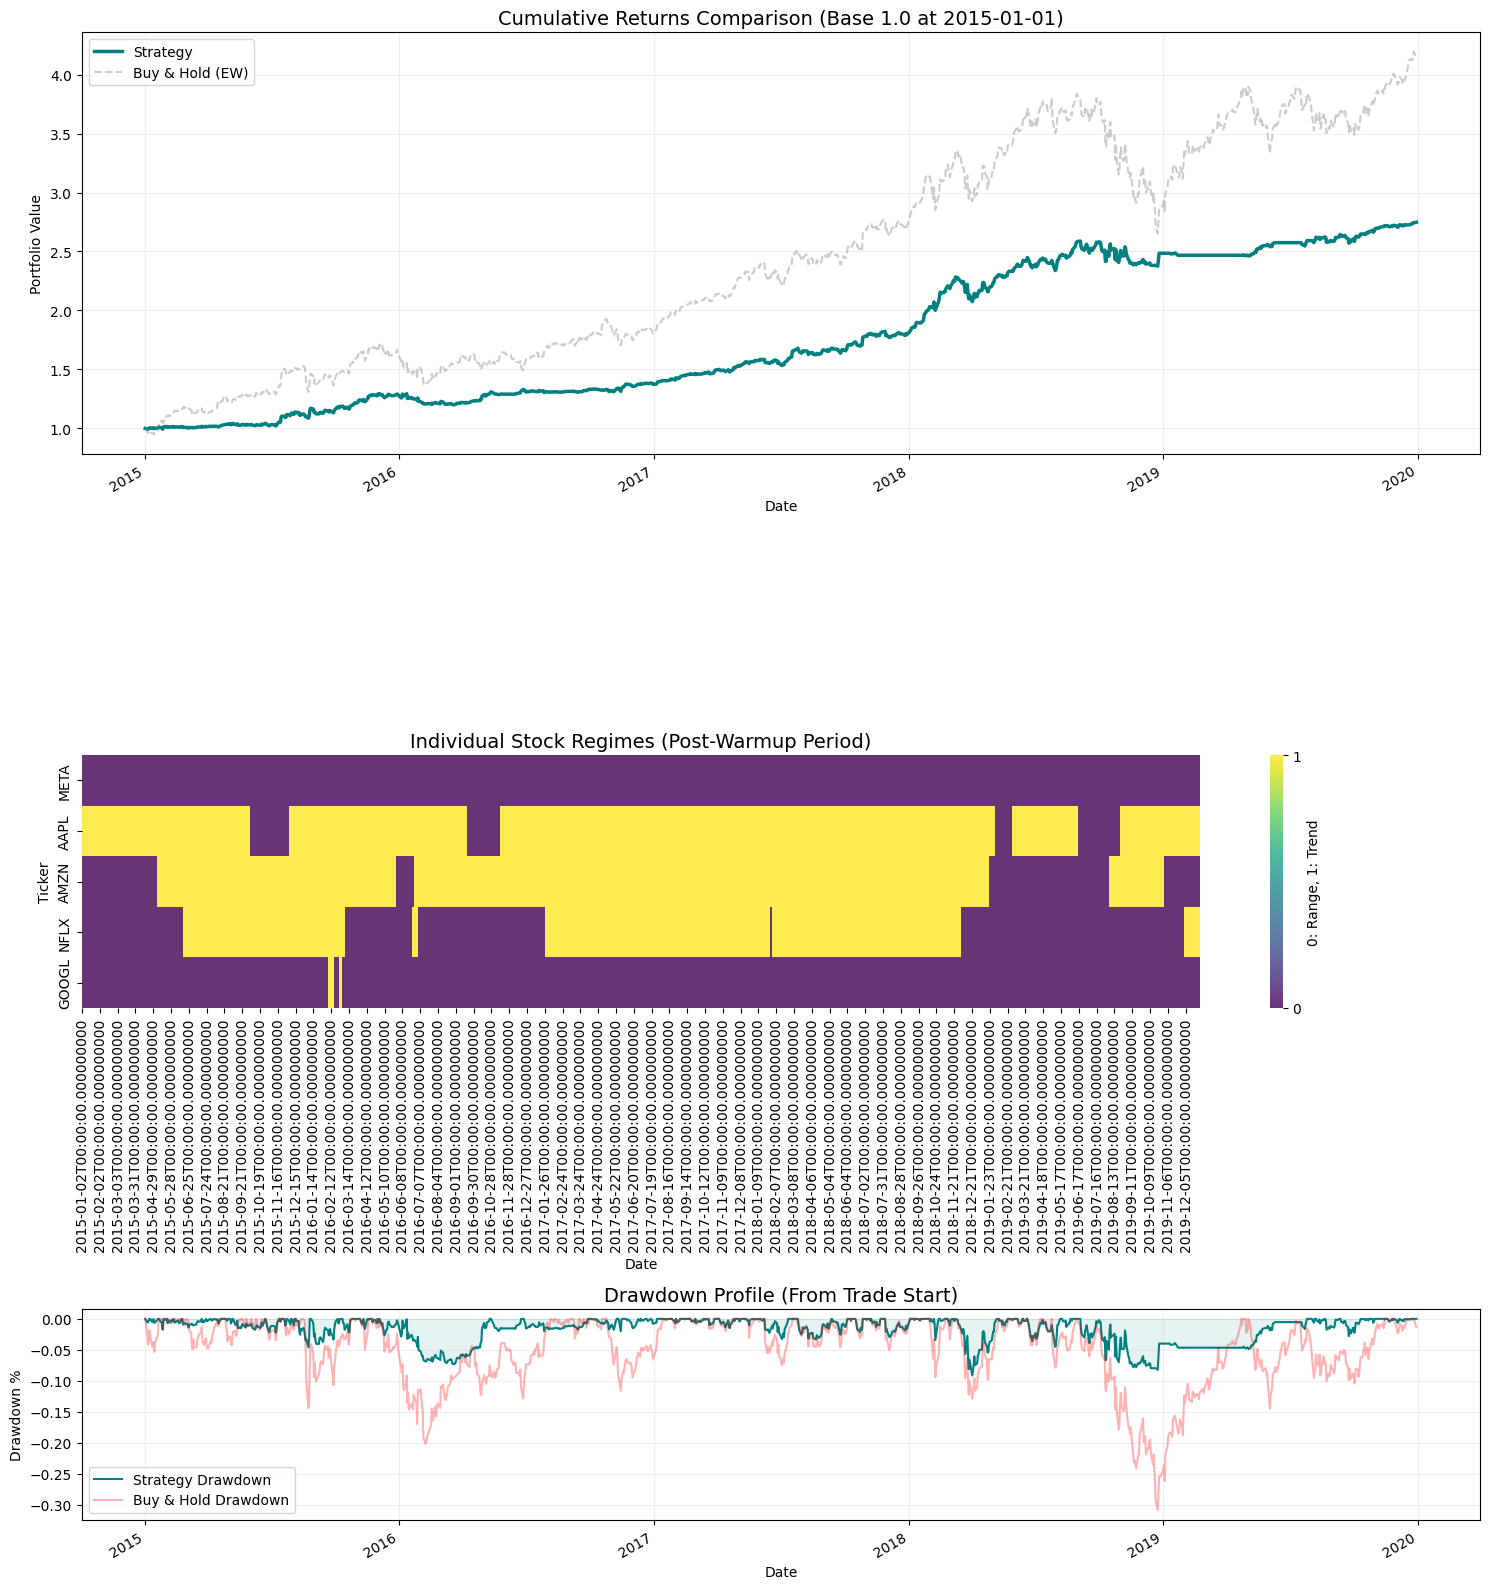


Success: Trade logs generated. Performance evaluation covers 2015-01-02 to 2019-12-30.


In [ ]:
# Slicing the returns to start only from TRADE_START
active_strat_rets = strat_rets[strat_rets.index >= TRADE_START]
active_bh_rets = bh_rets[bh_rets.index >= TRADE_START]

# Summary Stats
strat_m = get_metrics(active_strat_rets)
bh_m = get_metrics(active_bh_rets)
summary_df = pd.DataFrame([strat_m, bh_m], index=["Regime Strategy", "Buy & Hold"])

print(f"=== Performance Comparison (From {TRADE_START}) ===")
display(summary_df.style.format("{:.2%}", subset=["Return", "CAGR", "MaxDD"]).format("{:.2f}", subset=["Sharpe", "Sortino"]))

# Plots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 16), gridspec_kw={'height_ratios': [2, 1.2, 1]})

# 1. Equity Curve (Calculated from 1.0 at TRADE_START)
(1+active_strat_rets).cumprod().plot(ax=ax1, label="Strategy", color="teal", lw=2.5)
(1+active_bh_rets).cumprod().plot(ax=ax1, label="Buy & Hold (EW)", color="gray", alpha=0.4, ls="--")
ax1.set_title(f"Cumulative Returns Comparison (Base 1.0 at {TRADE_START})", fontsize=14)
ax1.set_ylabel("Portfolio Value")
ax1.legend()
ax1.grid(True, alpha=0.2)

# 2. Individual Stock Regime Heatmap (Slicing the map for visualization)
regime_t = regime_map[regime_map.index >= TRADE_START].T
sns.heatmap(regime_t, ax=ax2, cmap="viridis", cbar_kws={'label': '0: Range, 1: Trend', 'ticks': [0, 1]}, alpha=0.8)
ax2.set_title("Individual Stock Regimes (Post-Warmup Period)", fontsize=14)
ax2.set_xlabel("Date")
ax2.set_ylabel("Ticker")

# 3. Drawdown Comparison
equity_strat = (1+active_strat_rets).cumprod()
equity_bh = (1+active_bh_rets).cumprod()

dd_strat = equity_strat / equity_strat.cummax() - 1
dd_bh = equity_bh / equity_bh.cummax() - 1

dd_strat.plot(ax=ax3, label="Strategy Drawdown", color="teal", lw=1.5)
dd_bh.plot(ax=ax3, label="Buy & Hold Drawdown", color="red", alpha=0.3)
ax3.fill_between(dd_strat.index, dd_strat, color="teal", alpha=0.1)
ax3.set_title("Drawdown Profile (From Trade Start)", fontsize=14)
ax3.set_ylabel("Drawdown %")
ax3.legend()
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"\nSuccess: Trade logs generated. Performance evaluation covers {active_strat_rets.index[0].date()} to {active_strat_rets.index[-1].date()}.")

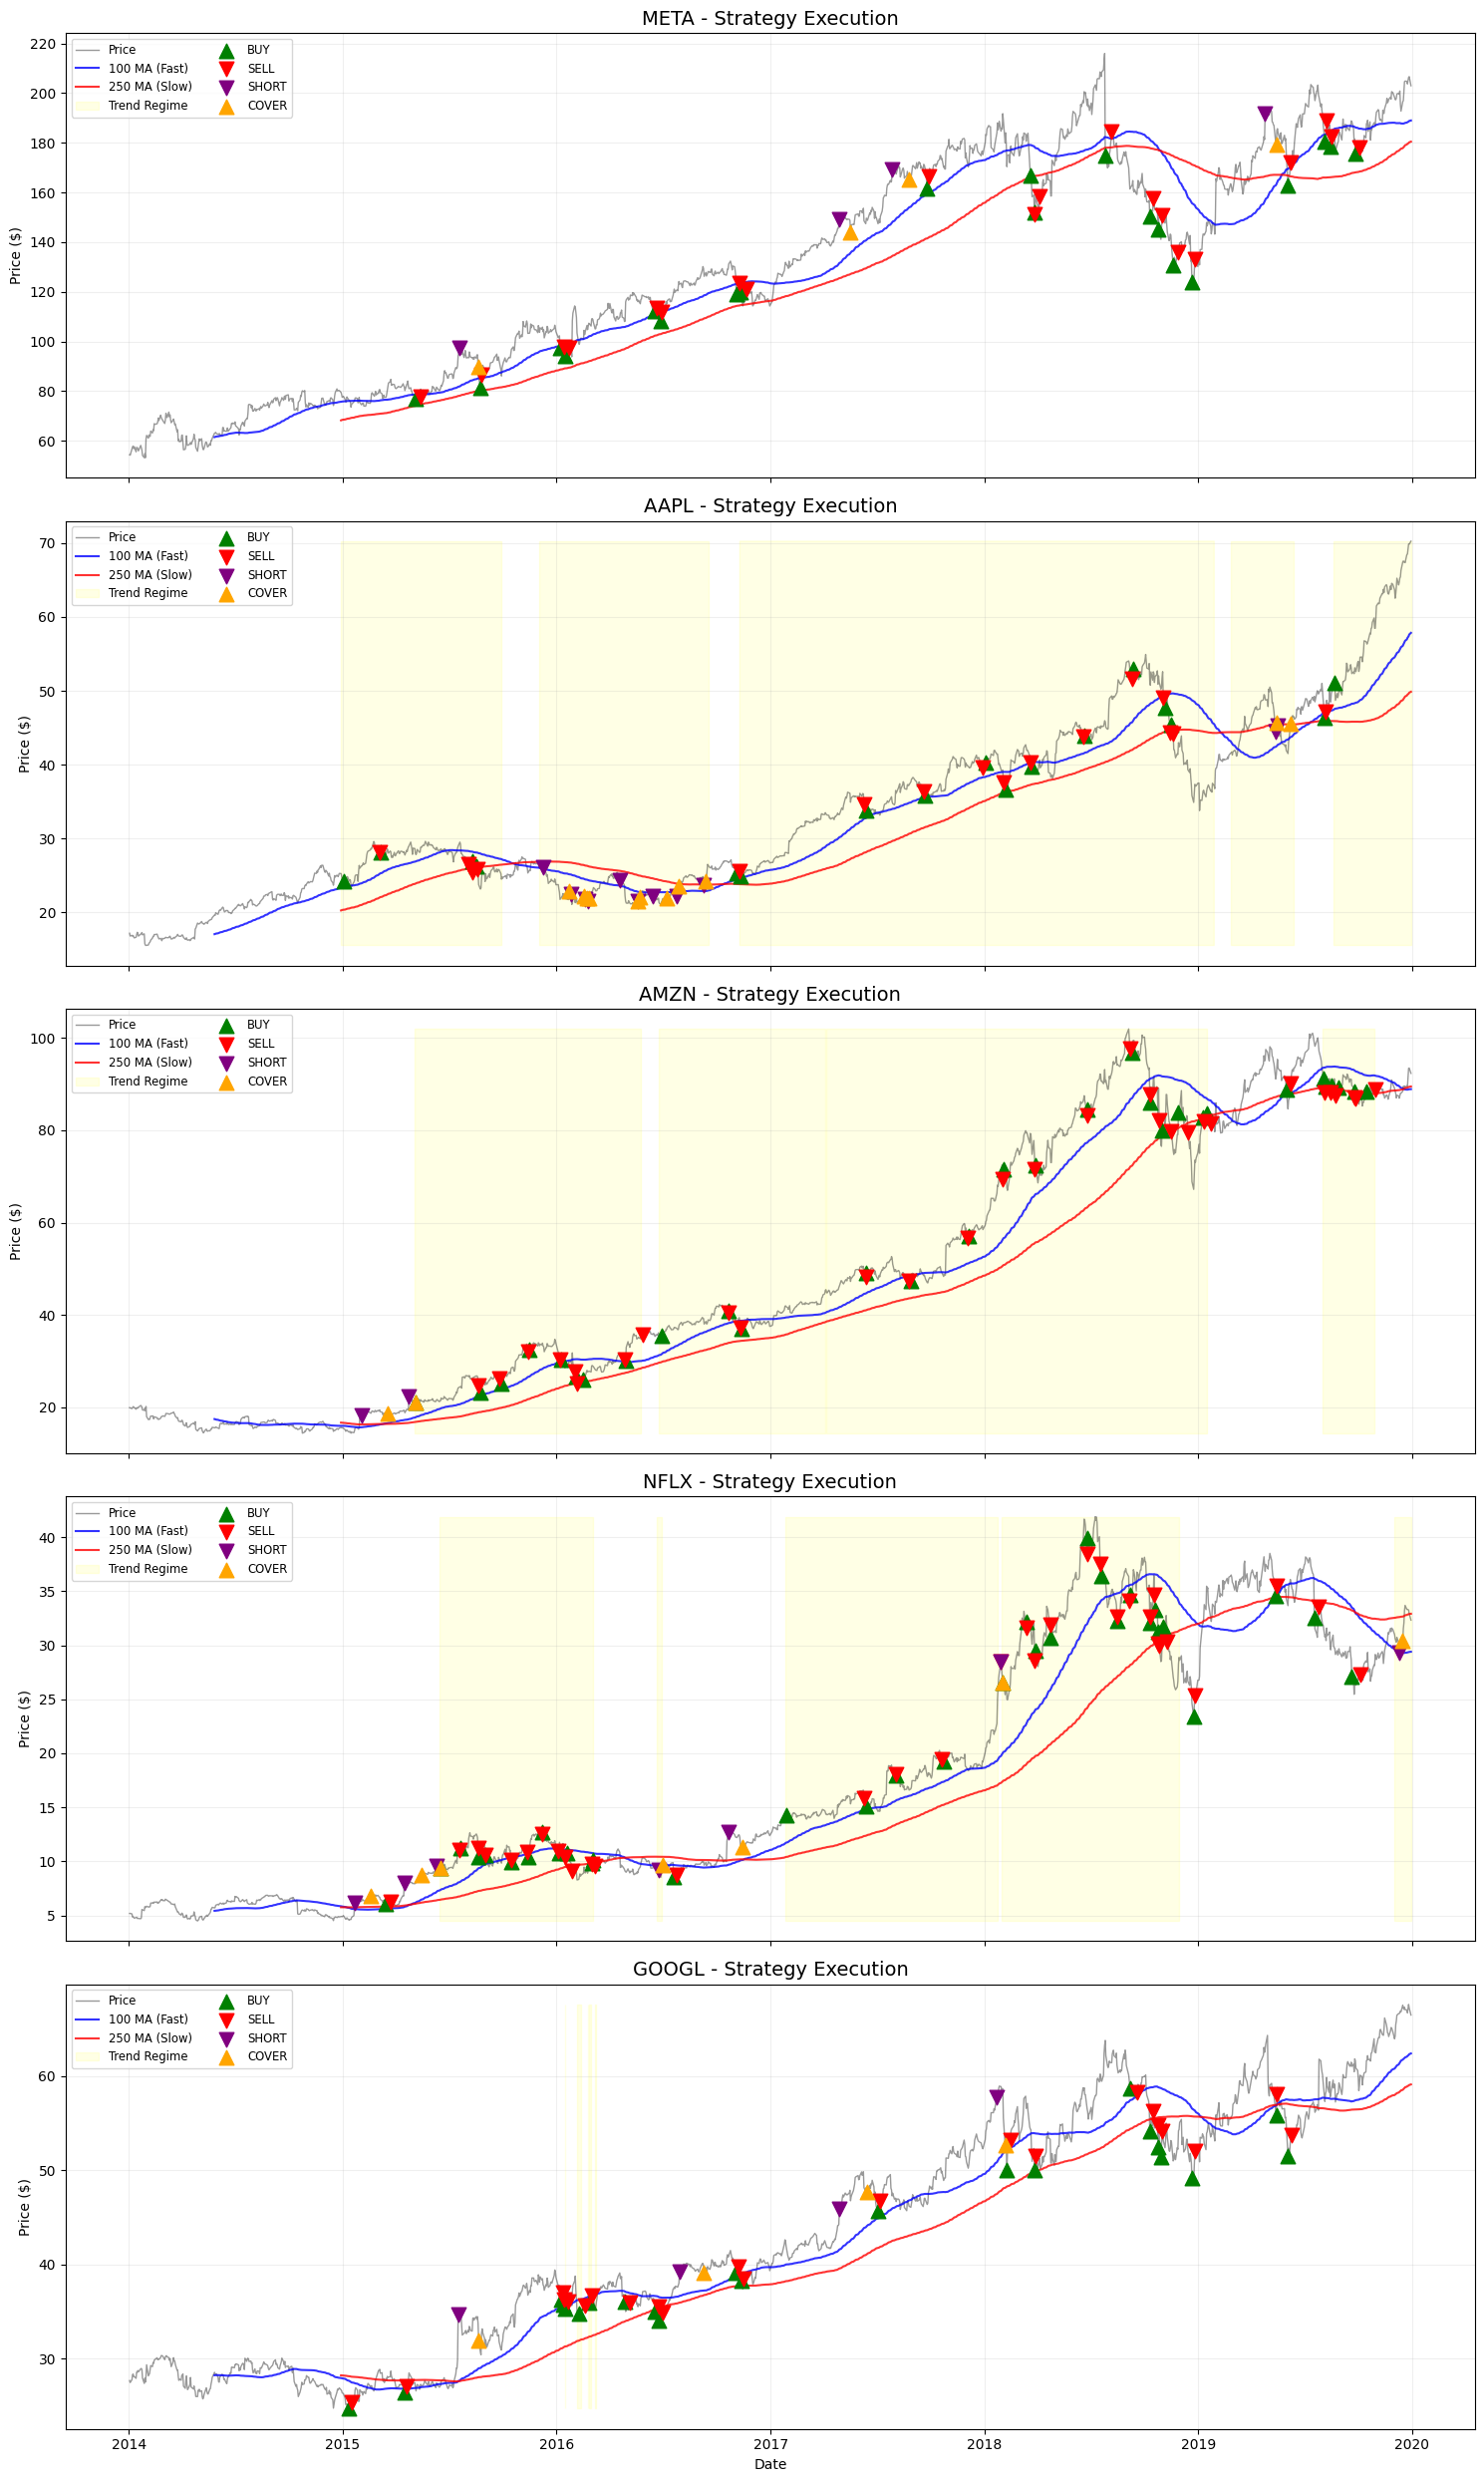

In [ ]:
# @title Moving Average Visualization with Strategy Signals
def plot_moving_averages_with_signals(prices_df, tickers, logs, params):
    n_stocks = len(tickers)
    fig, axes = plt.subplots(n_stocks, 1, figsize=(15, 5 * n_stocks), sharex=True)

    if n_stocks == 1:
        axes = [axes]

    for i, t in enumerate(tickers):
        # 1. Prepare Data
        c = prices_df[t].ffill().dropna()
        ma_f = c.rolling(window=params['MA_FAST']).mean()
        ma_s = c.rolling(window=params['MA_SLOW']).mean()

        # 2. Plot Price and MAs
        axes[i].plot(c.index, c.values, label='Price', color='black', alpha=0.4, lw=1)
        axes[i].plot(ma_f.index, ma_f.values, label=f"{params['MA_FAST']} MA (Fast)", color='blue', lw=1.5, alpha=0.8)
        axes[i].plot(ma_s.index, ma_s.values, label=f"{params['MA_SLOW']} MA (Slow)", color='red', lw=1.5, alpha=0.8)

        # 3. Highlight Trend Regime
        strength = (ma_f - ma_s).abs() / c
        is_trend = strength > params['TREND_THRESHOLDS'].get(t, 0.03)
        axes[i].fill_between(c.index, c.min(), c.max(), where=is_trend, color='yellow', alpha=0.1, label='Trend Regime')

        # 4. Overlay Trade Signals
        ticker_logs = logs[logs['Ticker'] == t]
        if len(ticker_logs) > 0:
            style = {
                'BUY':   dict(marker='^', color='green', s=110, label='BUY'),
                'SELL':  dict(marker='v', color='red',   s=110, label='SELL'),
                'SHORT': dict(marker='v', color='purple',s=110, label='SHORT'),
                'COVER': dict(marker='^', color='orange',s=110, label='COVER'),
            }

            for side, st in style.items():
                sub = ticker_logs[ticker_logs['Side'] == side]
                if len(sub) > 0:
                    axes[i].scatter(sub['Date'], sub['Price'], zorder=5, **st)

        # 5. Formatting
        axes[i].set_title(f"{t} - Strategy Execution", fontsize=14)
        axes[i].legend(loc='upper left', fontsize='small', ncol=2)
        axes[i].grid(True, alpha=0.2)
        axes[i].set_ylabel('Price ($)')

    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()

# Run the plotting function using the 'trades_df' generated in your backtest
plot_moving_averages_with_signals(prices, TICKERS, trades_df, best_params)


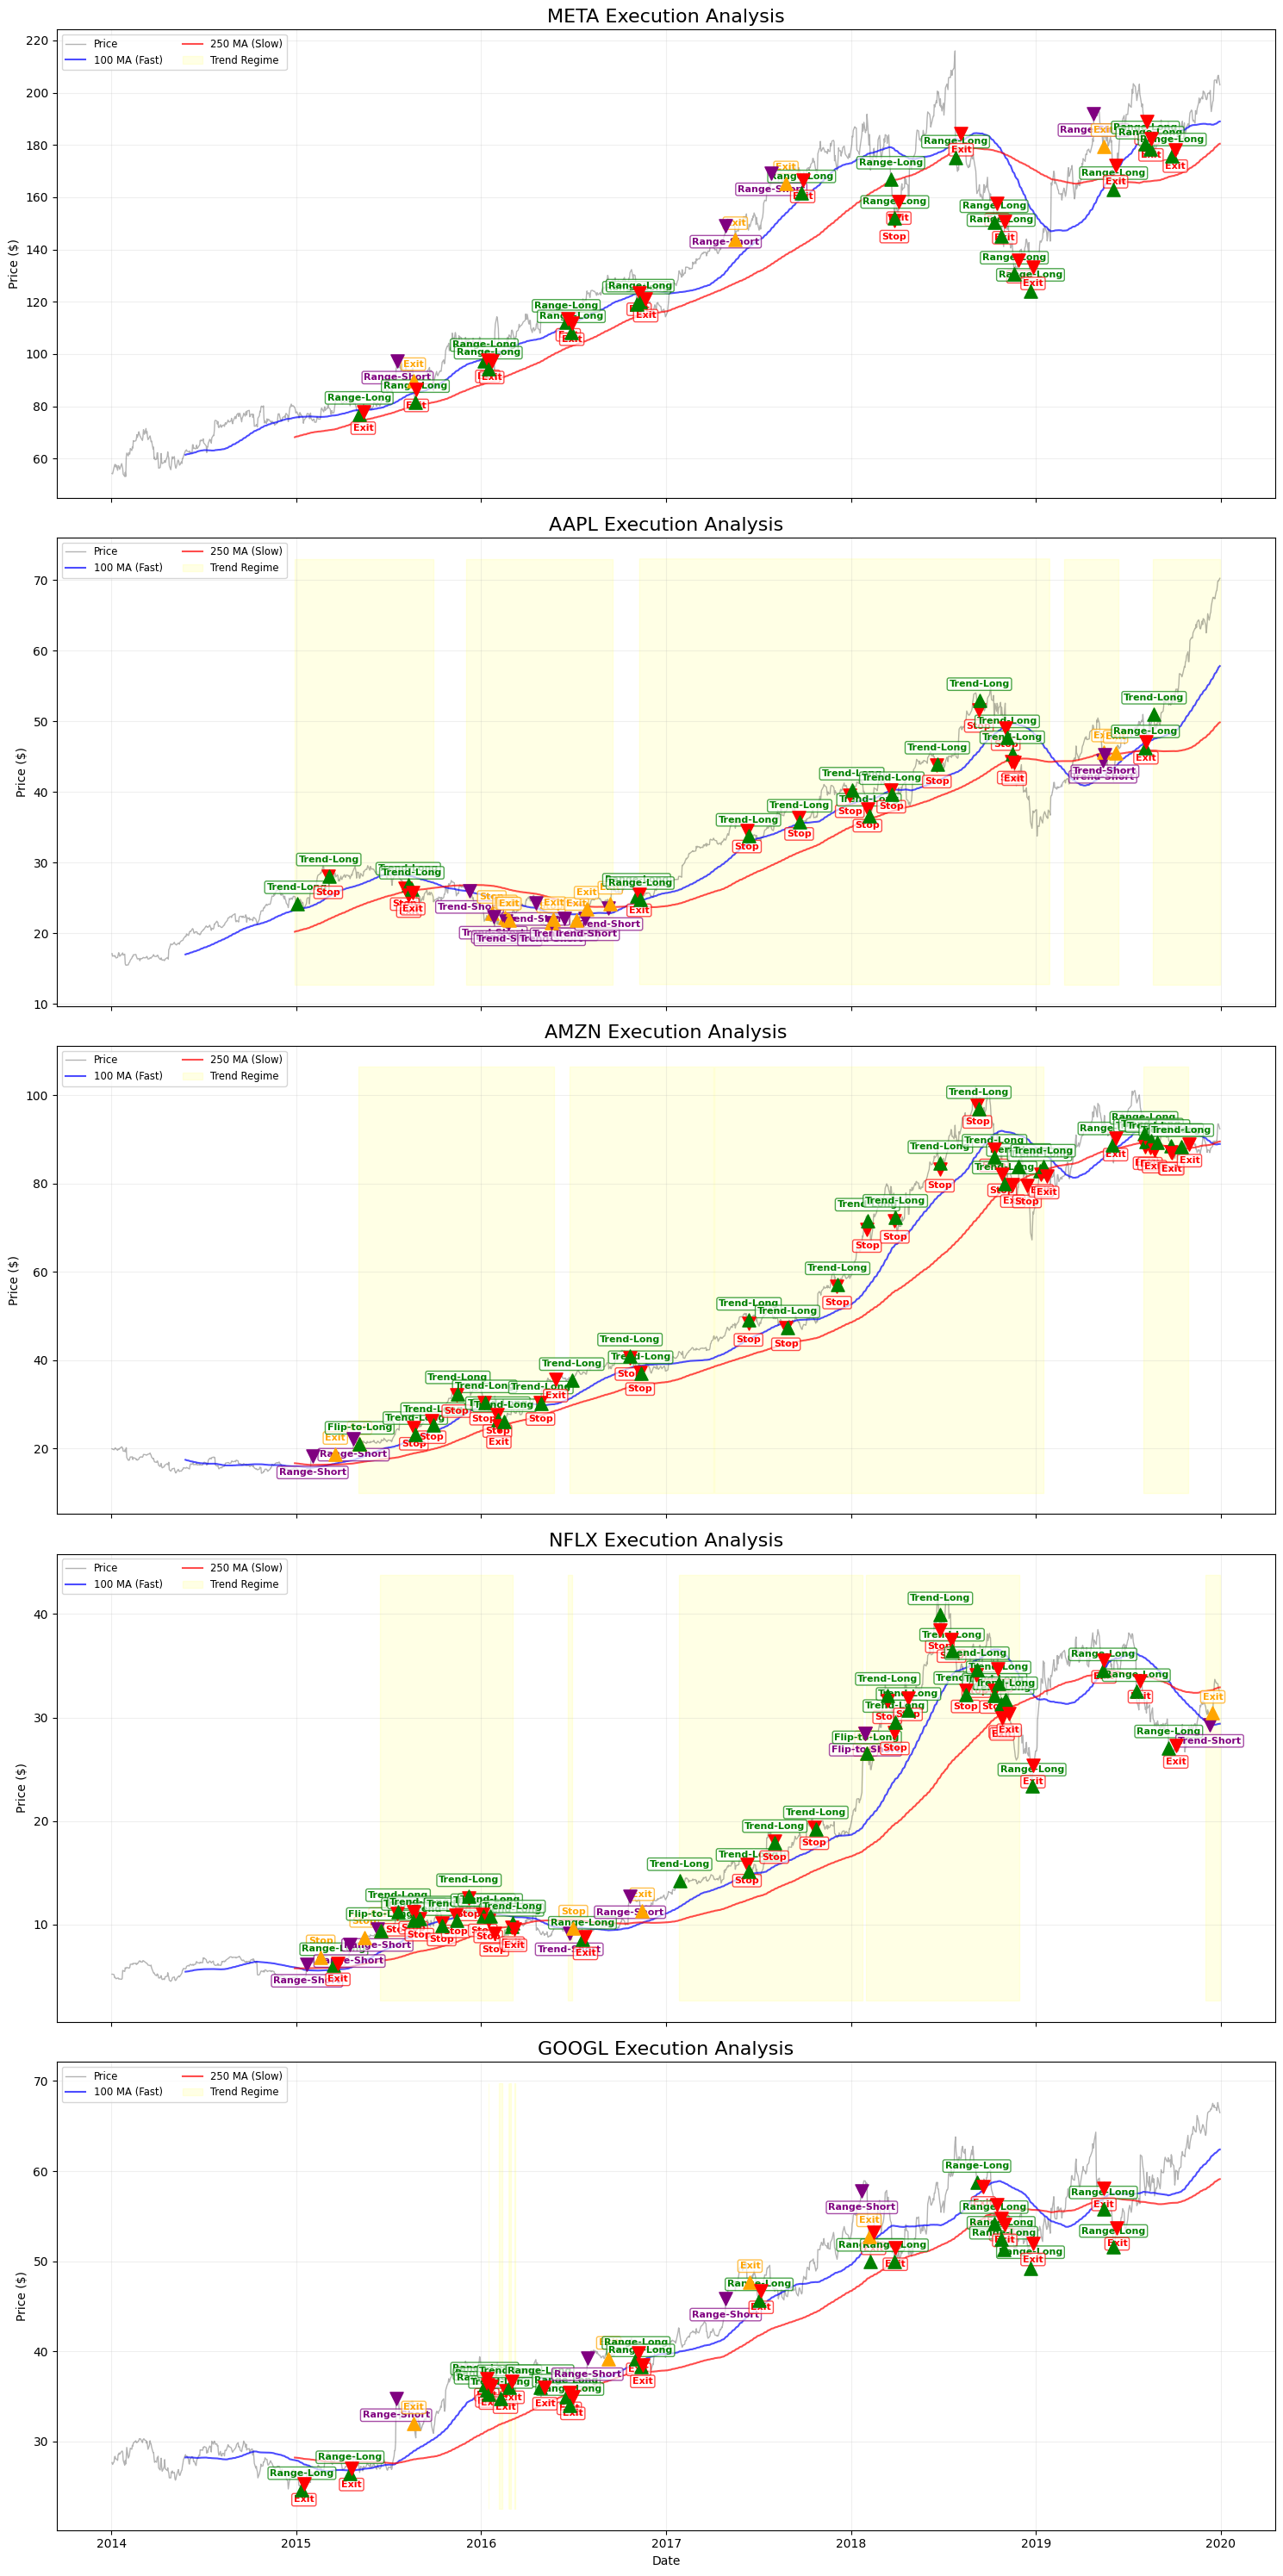

In [ ]:
# @title Moving Average Visualization with Trade Reasons
def plot_moving_averages_with_reasons(prices_df, tickers, logs, params):
    n_stocks = len(tickers)
    fig, axes = plt.subplots(n_stocks, 1, figsize=(15, 6 * n_stocks), sharex=True)

    if n_stocks == 1:
        axes = [axes]

    side_style = {
        'BUY':   dict(color='green',  marker='^'),
        'SELL':  dict(color='red',    marker='v'),
        'SHORT': dict(color='purple', marker='v'),
        'COVER': dict(color='orange', marker='^'),
    }

    for i, t in enumerate(tickers):
        # 1. Prepare Price and MA Data
        c = prices_df[t].ffill().dropna()
        ma_f = c.rolling(window=params['MA_FAST']).mean()
        ma_s = c.rolling(window=params['MA_SLOW']).mean()

        # 2. Plot Price and MAs
        axes[i].plot(c.index, c.values, label='Price', color='black', alpha=0.3, lw=1)
        axes[i].plot(ma_f.index, ma_f.values, label=f"{params['MA_FAST']} MA (Fast)", color='blue', lw=1.5, alpha=0.7)
        axes[i].plot(ma_s.index, ma_s.values, label=f"{params['MA_SLOW']} MA (Slow)", color='red', lw=1.5, alpha=0.7)

        # 3. Highlight Trend Regime
        strength = (ma_f - ma_s).abs() / c
        is_trend = strength > params['TREND_THRESHOLDS'].get(t, 0.03)
        axes[i].fill_between(c.index, axes[i].get_ylim()[0], axes[i].get_ylim()[1],
                             where=is_trend, color='yellow', alpha=0.1, label='Trend Regime')

        # 4. Filter Logs for this Ticker
        ticker_logs = logs[logs['Ticker'] == t]

        # 5. Overlay Signals with Text Reasons
        for _, row in ticker_logs.iterrows():
            side = row['Side']
            st = side_style.get(side, dict(color='gray', marker='o'))
            color = st['color']
            marker = st['marker']

            # marker position / label position
            va = 'bottom' if side in ('BUY','COVER') else 'top'
            xytext = (0, 10) if side in ('BUY','COVER') else (0, -10)

            axes[i].scatter(row['Date'], row['Price'], marker=marker, color=color, s=120, zorder=5)
            axes[i].annotate(str(row.get('Reason','')),
                             xy=(row['Date'], row['Price']),
                             xytext=xytext,
                             textcoords='offset points',
                             ha='center',
                             va=va,
                             fontsize=8,
                             fontweight='bold',
                             color=color,
                             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec=color))

        # 6. Formatting
        axes[i].set_title(f"{t} Execution Analysis", fontsize=16)
        axes[i].legend(loc='upper left', fontsize='small', ncol=2)
        axes[i].grid(True, alpha=0.2)
        axes[i].set_ylabel('Price ($)')

    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_moving_averages_with_reasons(prices, TICKERS, trades_df, best_params)


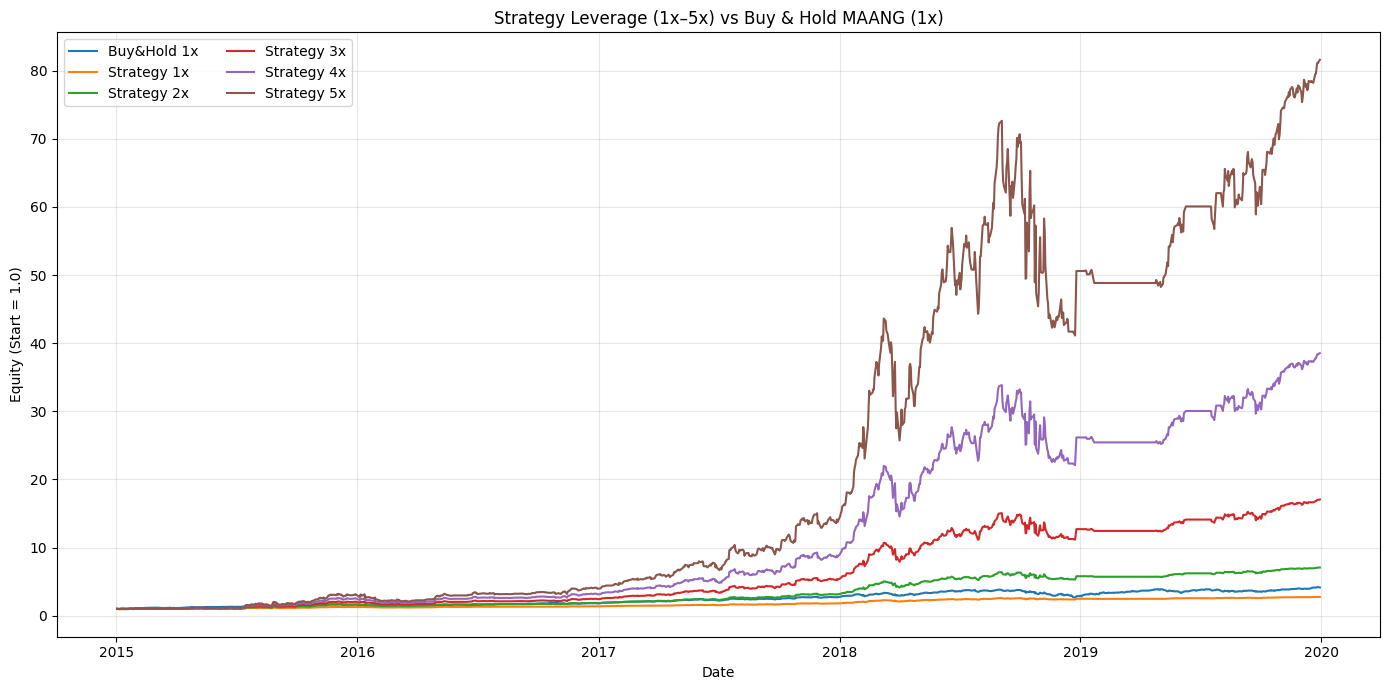

                Return      CAGR    Sharpe   Sortino     MaxDD
Series                                                        
Buy&Hold 1x   3.139096  0.329461  1.363249  1.797520 -0.309323
Strategy 1x   1.748268  0.224677  1.828526  2.338096 -0.091345
Strategy 2x   6.073505  0.480241  1.828526  2.338096 -0.178256
Strategy 3x  16.056423  0.765898  1.828526  2.338096 -0.260473
Strategy 4x  37.537620  1.079380  1.828526  2.338096 -0.347285
Strategy 5x  80.582339  1.416750  1.828526  2.338096 -0.433900


In [ ]:
def plot_strategy_leverage_vs_bh(
    strat_rets: pd.Series,
    prices: pd.DataFrame,
    tickers=TICKERS,
    trade_start=TRADE_START,
    leverages=(1, 2, 3, 4, 5),
    bh_weights=None,
    title="Strategy Leverage (1x–5x) vs Buy & Hold MAANG (1x)",
    clamp_floor=-0.99,   # prevent 1 + r from going <= 0; set None to disable
    show_metrics=True
):
    """
    Plots equity curves:
      - Strategy leveraged at 1x..5x
      - Buy & Hold MAANG at 1x (non-leveraged)

    Assumptions:
      - Levered daily return = L * daily_return
      - No financing costs / margin rules
      - Buy & Hold MAANG is equal-weight unless bh_weights provided
      - Optional clamp_floor to avoid impossible <= -100% daily returns

    Returns:
      equity_df, metrics_table (or None if show_metrics=False)
    """

    # --- Strategy returns slice ---
    strat_rets = strat_rets.dropna()
    strat_rets = strat_rets[strat_rets.index >= pd.Timestamp(trade_start)]

    # --- Buy & Hold MAANG (1x) ---
    px = prices[tickers].ffill()
    bh_rets_df = px.pct_change()

    # weights
    if bh_weights is None:
        w = pd.Series(1.0 / len(tickers), index=tickers)
    else:
        w = pd.Series(bh_weights).reindex(tickers).fillna(0.0)
        if w.sum() == 0:
            raise ValueError("bh_weights sums to 0. Provide valid weights.")
        w = w / w.sum()

    bh_rets = (bh_rets_df * w).sum(axis=1)

    # --- Align dates ---
    common_idx = strat_rets.index.intersection(bh_rets.index)
    strat_rets = strat_rets.loc[common_idx]
    bh_rets = bh_rets.loc[common_idx]

    # --- Equity curves ---
    equity = pd.DataFrame(index=common_idx)
    equity["Buy&Hold 1x"] = (1 + bh_rets).cumprod()

    for L in leverages:
        lev = strat_rets * L
        if clamp_floor is not None:
            lev = lev.clip(lower=clamp_floor)
        equity[f"Strategy {L}x"] = (1 + lev).cumprod()

    # --- Plot ---
    plt.figure(figsize=(14, 7))
    for col in equity.columns:
        plt.plot(equity.index, equity[col], label=col)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity (Start = 1.0)")
    plt.legend(ncols=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Optional metrics ---
    metrics_table = None
    if show_metrics:
        rows = []
        # BH metrics
        rows.append({"Series": "Buy&Hold 1x", **get_metrics(bh_rets)})

        # Strategy metrics per leverage
        for L in leverages:
            lev = strat_rets * L
            if clamp_floor is not None:
                lev = lev.clip(lower=clamp_floor)
            rows.append({"Series": f"Strategy {L}x", **get_metrics(lev)})

        metrics_table = pd.DataFrame(rows).set_index("Series")[["Return", "CAGR", "Sharpe", "Sortino", "MaxDD"]]
        print(metrics_table)

    return equity, metrics_table

equity, mt = plot_strategy_leverage_vs_bh(
    strat_rets=strat_rets,
    prices=prices,
    tickers=TICKERS,
    trade_start=TRADE_START,
    leverages=(1,2,3,4,5),
    bh_weights=None,   # equal-weight MAANG
    clamp_floor=-0.99, # keep (1+r) positive; set None to disable
    show_metrics=True
)